In [1]:
from pathlib import Path
import re
from collections import defaultdict

import awkward as ak
import numpy as np
import uproot
import h5py
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import networkx as nx
    HAS_NETWORKX = True
except Exception:
    HAS_NETWORKX = False

np.set_printoptions(suppress=True, precision=4)

In [2]:
# ============================================================
# User settings
# ============================================================

ROOT_FILE = Path("/media/hdd/ddicroce/data/MuonBucketDump_HNL2_ctau1000/outputs/MuonBucketDump_group.det-muon.48959404.EXT0._000005.RDO.root")

OUTPUT_DIR = Path("./data")
OUTPUT_NAME = "displaced_vertex_debug"

# ATLAS outer calorimeter envelope (approx.)
R_MAX =  8000.0   # mm
Z_MAX = 12000.0   # mm

# Muon-muon graph-building hyperparameters
MAX_DELTA_THETA_DEG = 35.0
MAX_DELTA_SECTOR = 1
SECTOR_MOD = 16

# Calo matching / neighborhood in (phi, eta)
MIN_E_CALO              = 200.0
MAX_DELTA_PHI_MUON_CALO = 0.5
MAX_DELTA_ETA_MUON_CALO = 0.5
MAX_DELTA_PHI_CALO_CALO = 0.5
MAX_DELTA_ETA_CALO_CALO = 0.5

# Keep events if they have vertex + muons. Calo is optional by default.
REQUIRE_CALO = False

# Event debug selection
EVENT_INDEX = 1

ARROW_LENGTH = 5000.0
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

In [3]:
def _normalize_keys(keys):
    return {re.sub(r"\[.*\]/[A-Za-z]$", "", k): k for k in keys}

def _open_tree_by_name(root_file, tree_name):
    f = uproot.open(root_file)
    if tree_name not in f:
        candidates = [k.split(";")[0] for k in f.keys()]
        raise ValueError(f"Tree '{tree_name}' not found. Available: {candidates}")
    obj = f[tree_name]
    _ = obj.num_entries
    return obj

def _flatten_event_hash(x):
    arr = np.asarray(x).ravel()
    if arr.size == 0:
        return None
    if arr.size < 2:
        return (int(arr[0]), -1)
    return (int(arr[0]), int(arr[1]))


In [4]:
f = uproot.open(ROOT_FILE)
list(f.keys())

['CaloDump;1', 'MuonBucketDump;1', 'MuonVertexDump;1']

In [5]:
for tree_name in ["MuonBucketDump", "CaloDump", "MuonVertexDump"]:
    tree = _open_tree_by_name(ROOT_FILE, tree_name)
    clean = _normalize_keys(list(tree.keys()))
    print(f"\n[{tree_name}] entries = {tree.num_entries}")
    for k in sorted(clean.keys()):
        print("  ", k)


[MuonBucketDump] entries = 12468
   CommonEventHash
   Layer
   adc
   bucket_chamberIndex
   bucket_hasTruth
   bucket_layers
   bucket_max
   bucket_min
   bucket_ml_score_class0
   bucket_ml_score_class1
   bucket_ml_score_class2
   bucket_positionX
   bucket_positionY
   bucket_positionZ
   bucket_sector
   bucket_segments
   bucket_side
   bucket_spacePoints
   covX
   covY
   dimension
   driftR
   globalPositionX
   globalPositionY
   globalPositionZ
   id_stationEta
   id_stationIndex
   id_stationPhi
   isMdt
   isStrip
   localPositionX
   localPositionY
   localPositionZ
   measuresEta
   measuresPhi
   nEtaInUse
   nPhiInUse
   nSegments
   segmentDirectionX
   segmentDirectionY
   segmentDirectionZ
   segmentLocalPhi
   segmentLocalTheta
   segmentLocalX
   segmentLocalY
   segmentPositionX
   segmentPositionY
   segmentPositionZ
   segmentTruthPart
   segment_chiSquared
   segment_numberDoF
   sp_seg_matching
   spacePoint_truthSegLink
   tdc
   trueLabel
   truthSegment

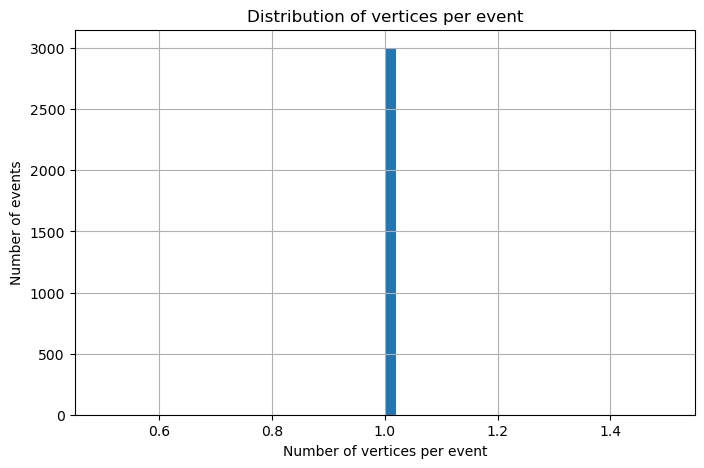

In [6]:
vertex_x = tree["truthMuonVertexPositionX"].array()
num_vertices_per_event = ak.num(vertex_x)

plt.figure(figsize=(8,5))
plt.hist(num_vertices_per_event, bins=50)
plt.xlabel("Number of vertices per event")
plt.ylabel("Number of events")
plt.title("Distribution of vertices per event")
plt.grid(True)

plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325


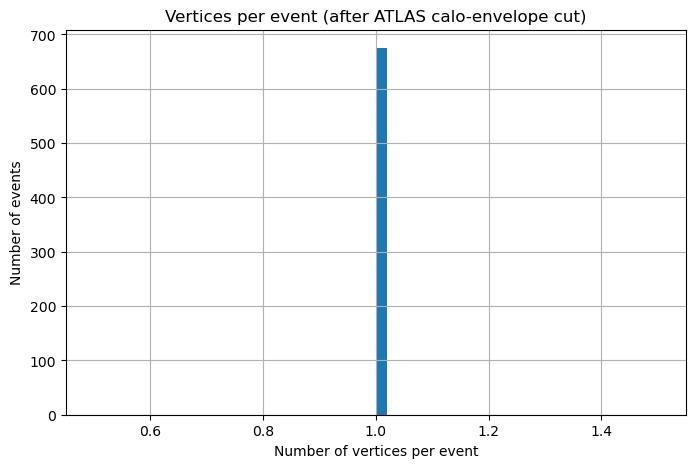

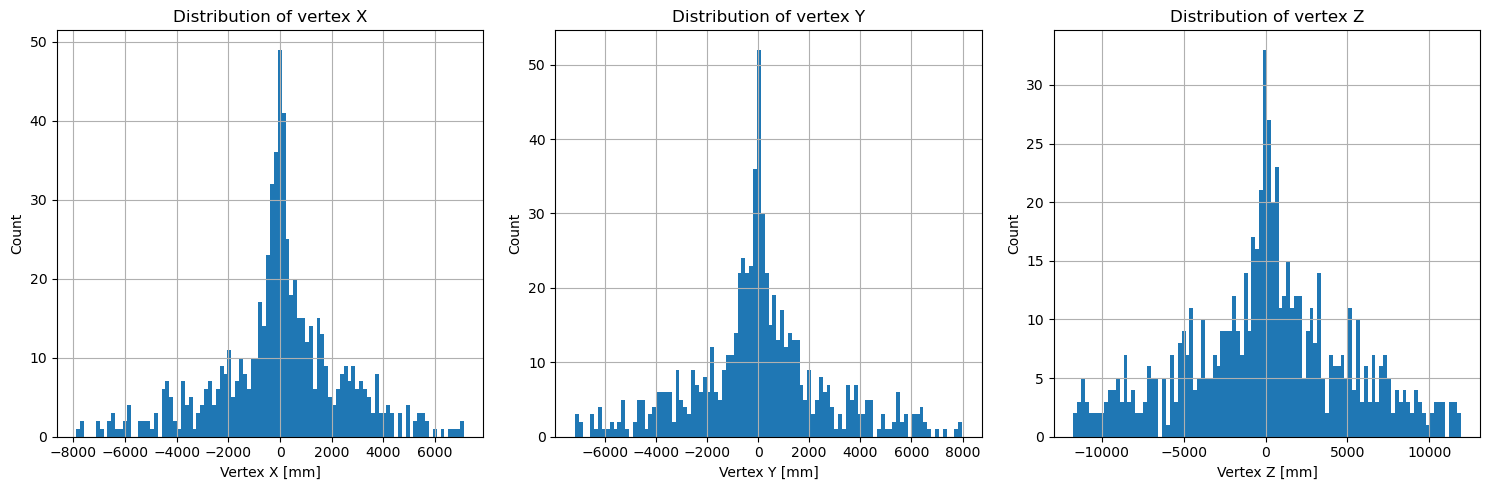

In [7]:
# ------------------------------------------------------------
# Read the vertex tree explicitly
# ------------------------------------------------------------
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")

vertex_x = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z = vertex_tree["truthMuonVertexPositionZ"].array()

# ------------------------------------------------------------
# Build per-vertex and per-event masks
# Keep an event only if ALL its vertices are inside the
# ATLAS outer calorimeter envelope
# ------------------------------------------------------------
vertex_r = np.sqrt(vertex_x**2 + vertex_y**2)

vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z) <= Z_MAX)

# Event-level mask: keep only events where every vertex is inside
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

# ------------------------------------------------------------
# Filter the vertex arrays
# ------------------------------------------------------------
vertex_x_filt = vertex_x[event_mask]
vertex_y_filt = vertex_y[event_mask]
vertex_z_filt = vertex_z[event_mask]

# Example: new multiplicity distribution after filtering
num_vertices_per_event = ak.num(vertex_x_filt)

plt.figure(figsize=(8,5))
plt.hist(num_vertices_per_event, bins=50)
plt.xlabel("Number of vertices per event")
plt.ylabel("Number of events")
plt.title("Vertices per event (after ATLAS calo-envelope cut)")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Flatten for coordinate distributions after filtering
# ------------------------------------------------------------
vx = ak.to_numpy(ak.flatten(vertex_x_filt))
vy = ak.to_numpy(ak.flatten(vertex_y_filt))
vz = ak.to_numpy(ak.flatten(vertex_z_filt))

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(vx, bins=100)
axes[0].set_xlabel("Vertex X [mm]")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of vertex X")
axes[0].grid(True)

axes[1].hist(vy, bins=100)
axes[1].set_xlabel("Vertex Y [mm]")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of vertex Y")
axes[1].grid(True)

axes[2].hist(vz, bins=100)
axes[2].set_xlabel("Vertex Z [mm]")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of vertex Z")
axes[2].grid(True)

plt.tight_layout()
plt.show()

First 10 events muon counts: [2, 3, 3, 3, 3, 4, 3, 3, 3, 3]


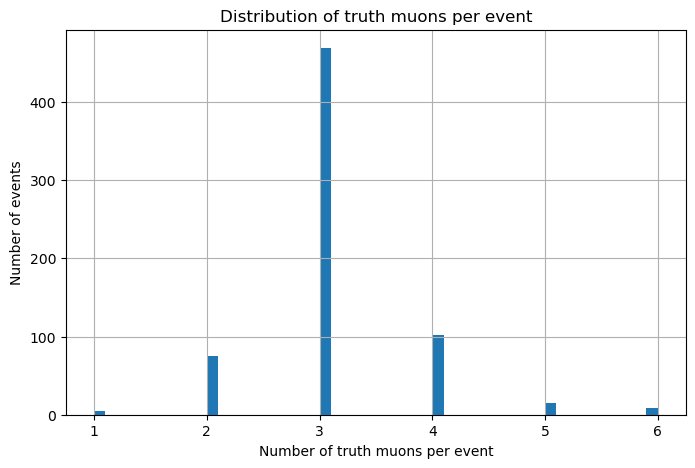

In [8]:
muon_pt = tree["truthMuon_pt"].array()

muon_pt_filt = muon_pt[event_mask]

# Number of muons per event
num_muons_per_event = ak.num(muon_pt_filt)

print("First 10 events muon counts:", num_muons_per_event[:10])

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(num_muons_per_event, bins=50)
plt.xlabel("Number of truth muons per event")
plt.ylabel("Number of events")
plt.title("Distribution of truth muons per event")
plt.grid(True)

plt.show()

# Muon info

In [9]:
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
bucket_hash_branch = bucket_keys["CommonEventHash"]
bucket_hashes = bucket_tree[bucket_hash_branch].array()

vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
vertex_hash_branch = vertex_keys["CommonEventHash"]
vertex_hashes = vertex_tree[vertex_hash_branch].array()

# event chosen in filtered vertex tree
vertex_hashes_filt = vertex_hashes[event_mask]
vertex_event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print("Vertex event hash:", vertex_event_hash)
print("Vertex position (x,y,z):",
      vertex_x_filt[EVENT_INDEX],
      vertex_y_filt[EVENT_INDEX],
      vertex_z_filt[EVENT_INDEX])

# Find ALL bucket entries with same hash in original bucket tree
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes)
    if _flatten_event_hash(h) == vertex_event_hash
]

print("Number of MuonBucketDump entries with same event hash:", len(matching_bucket_indices))
print("First matching indices:", matching_bucket_indices[:20])

total_segments = 0
for i in matching_bucket_indices:
    bx = bucket_tree["bucket_positionX"].array(entry_start=i, entry_stop=i+1)[0]
    by = bucket_tree["bucket_positionY"].array(entry_start=i, entry_stop=i+1)[0]
    bz = bucket_tree["bucket_positionZ"].array(entry_start=i, entry_stop=i+1)[0]

    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    nseg = len(segx)
    total_segments += nseg

    print(f"bucket entry {i}: bucket=({bx:.1f}, {by:.1f}, {bz:.1f}), nSegments={nseg}")

print("Total segments across event:", total_segments)


Vertex event hash: (9014, 2211873798111632)
Vertex position (x,y,z): [140] [263] [-839]
Number of MuonBucketDump entries with same event hash: 10
First matching indices: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
bucket entry 23: bucket=(4209.0, 4217.9, -14272.8), nSegments=1
bucket entry 24: bucket=(2041.3, 4949.5, -14272.8), nSegments=1
bucket entry 25: bucket=(-7649.7, -7658.7, -14272.8), nSegments=1
bucket entry 26: bucket=(-6180.7, -6180.7, -11323.0), nSegments=1
bucket entry 27: bucket=(-6720.5, -6720.5, -12011.7), nSegments=1
bucket entry 28: bucket=(3080.7, 7437.4, -21840.5), nSegments=1
bucket entry 29: bucket=(6724.9, 6724.9, -21424.5), nSegments=1
bucket entry 30: bucket=(-5050.8, -5050.8, -8958.7), nSegments=1
bucket entry 31: bucket=(2091.3, 2091.3, -7570.7), nSegments=0
bucket entry 32: bucket=(1054.8, 2546.6, -7177.0), nSegments=0
Total segments across event: 8


In [10]:
# dictionary: event_hash -> number of segments
segment_x = bucket_tree["segmentPositionX"].array()
segments_per_event = defaultdict(int)

for h, segx in zip(bucket_hashes, segment_x):

    event_hash = _flatten_event_hash(h)

    nseg = len(segx)

    segments_per_event[event_hash] += nseg

vertex_hashes_kept = {
    _flatten_event_hash(h)
    for h in vertex_hashes[event_mask]
}

segments_per_event_kept = {
    h: n
    for h, n in segments_per_event.items()
    if h in vertex_hashes_kept
}

segments_per_event_values = np.array(list(segments_per_event_kept.values()))

print("Number of events:", len(segments_per_event_values))
print("Mean segments/event:", segments_per_event_values.mean())
print("Max segments/event:", segments_per_event_values.max())

Number of events: 662
Mean segments/event: 6.311178247734139
Max segments/event: 19


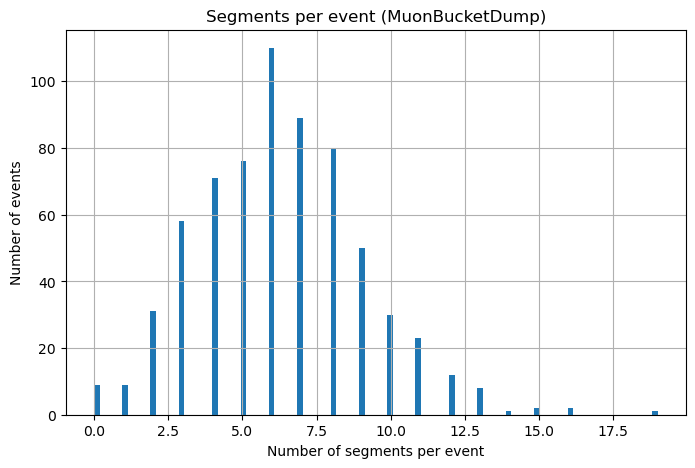

In [11]:
plt.figure(figsize=(8,5))

plt.hist(segments_per_event_values, bins=100)

plt.xlabel("Number of segments per event")
plt.ylabel("Number of events")
plt.title("Segments per event (MuonBucketDump)")

plt.grid(True)

plt.show()

# Plot event

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using first filtered event: index 0
Number of vertices in event: 1
Number of muons in event   : 2
mu_links = [[0, 1]]


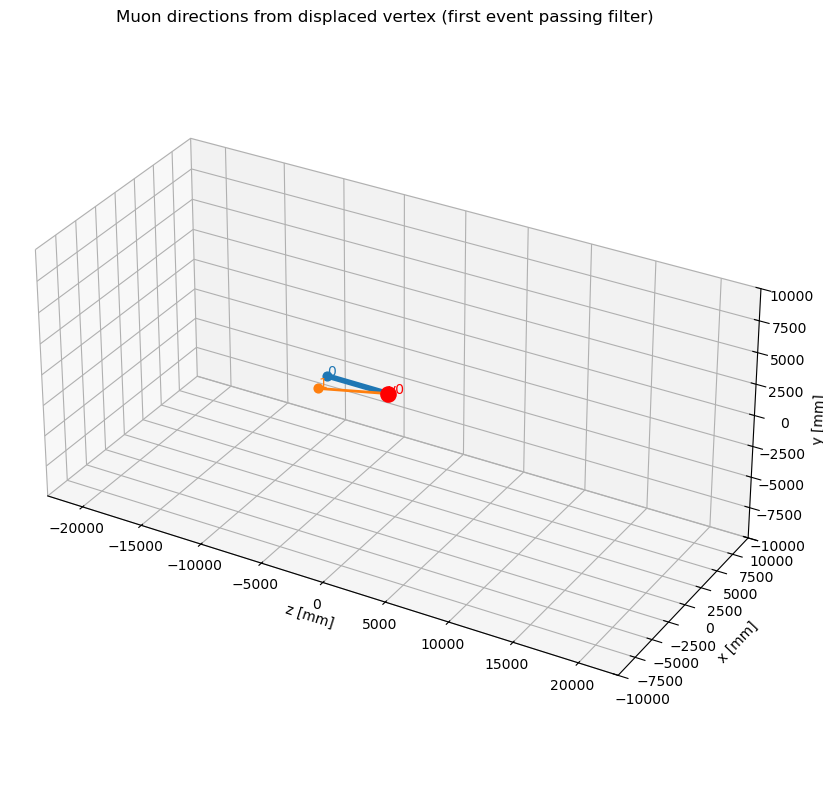

In [12]:
# ============================================================
# Read vertex tree
# ============================================================

vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")

vertex_x = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z = vertex_tree["truthMuonVertexPositionZ"].array()

# Muon truth branches
muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()


# ============================================================
# Event filter: keep events where ALL vertices are inside calo
# ============================================================

vertex_r = np.sqrt(vertex_x**2 + vertex_y**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z) <= Z_MAX)

# Event-level mask: every vertex in the event must satisfy the cut
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")


# ============================================================
# Filter arrays
# ============================================================

vertex_x_filt = vertex_x[event_mask]
vertex_y_filt = vertex_y[event_mask]
vertex_z_filt = vertex_z[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]


# ============================================================
# Pick first event that passed filter
# ============================================================

event_index = 0

vx_evt = vertex_x_filt[event_index]
vy_evt = vertex_y_filt[event_index]
vz_evt = vertex_z_filt[event_index]

mu_pt  = muon_pt_filt[event_index]
mu_eta = muon_eta_filt[event_index]
mu_phi = muon_phi_filt[event_index]

print(f"\nUsing first filtered event: index {event_index}")
print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))


# ============================================================
# Build mu_links
# ============================================================
# Simple assumption for visualization:
# every vertex is connected to all muons in the event.
# If you have a real vertex->muon association, replace this.
# ============================================================

n_vertices = len(vx_evt)
n_muons = len(mu_pt)

mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

print("mu_links =", mu_links)


# ============================================================
# Plot
# axes are remapped as:
#   plot X = physical z
#   plot Y = physical x
#   plot Z = physical y
# ============================================================

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap coordinates: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    # draw vertex
    ax.scatter(Xv, Yv, Zv, s=120, color="red")
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color="red")

    for i_link, imu in enumerate(links):
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        lw = max(1, 4 - (i_link * 2))
        color = COLORS[i_link % len(COLORS)]

        # shaft
        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=color,
            linewidth=lw
        )

        # tip marker
        ax.scatter(Xt, Yt, Zt, color=color, s=40)

        # muon label
        ax.text(Xt, Yt, Zt, f"{imu}", fontsize=10, color=color)

ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

# Fixed detector view limits
ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Muon directions from displaced vertex (first event passing filter)")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 1
Event hash: (9014, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 10
Matching bucket indices: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
bucket entry 23: nSegments=1
bucket entry 24: nSegments=1
bucket entry 25: nSegments=1
bucket entry 26: nSegments=1
bucket entry 27: nSegments=1
bucket entry 28: nSegments=1
bucket entry 29: nSegments=1
bucket entry 30: nSegments=1
bucket entry 31: nSegments=0
bucket entry 32: nSegments=0
Total segments found: 8


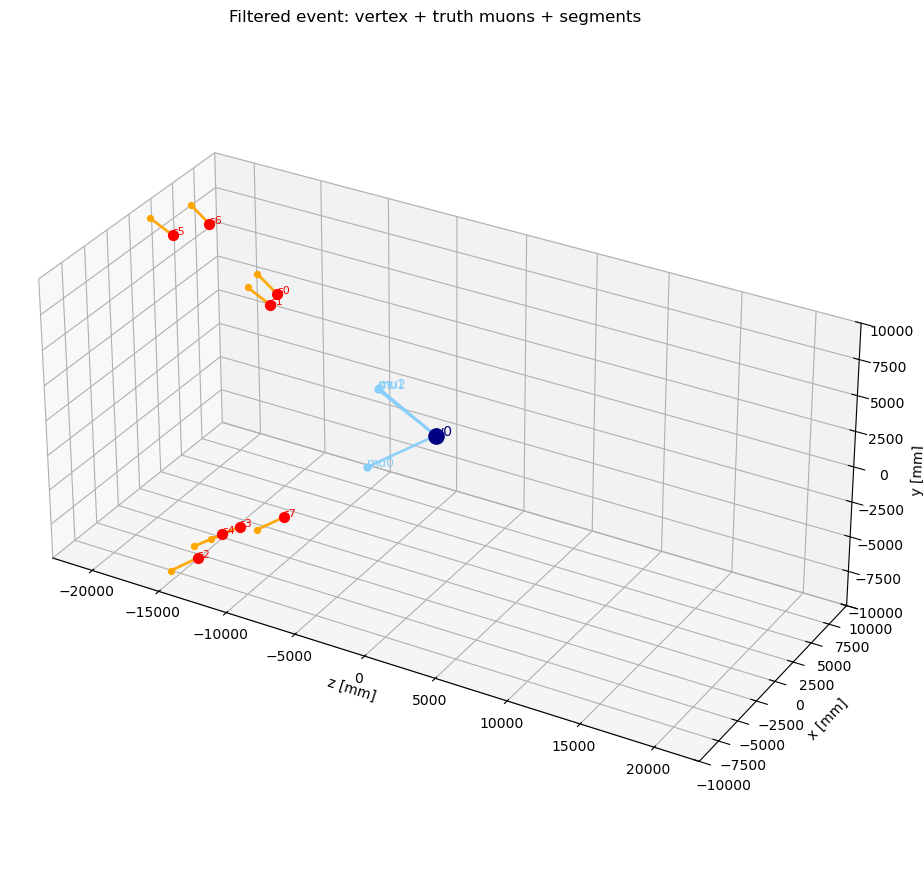

In [13]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX = 1                 # index in the FILTERED vertex tree
MUON_ARROW_LENGTH = 5000.0      # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the calorimeter envelope
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# Filter arrays
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find ALL MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # segment position remap
    Xs = sz
    Ys = sx
    Zs = sy

    # red dot for segment position
    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction: (x, y, z) -> (z, x, y)
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Geometry for CALORIMETER outer envelope
# Use values appropriate for your detector definition
# ============================================================
CALO_R_MAX = 4250.0   # mm  example barrel outer radius
CALO_Z_MAX = 6500.0   # mm  example endcap |z| extent

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def unit_vector_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with a cylinder+endcap
    envelope defined by:
        r = r_max
        |z| = z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = unit_vector_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel cylinder: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcap planes: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(t for t in candidates if t > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 1
Event hash: (9014, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 10
Matching bucket indices: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
bucket entry 23: nSegments=1
bucket entry 24: nSegments=1
bucket entry 25: nSegments=1
bucket entry 26: nSegments=1
bucket entry 27: nSegments=1
bucket entry 28: nSegments=1
bucket entry 29: nSegments=1
bucket entry 30: nSegments=1
bucket entry 31: nSegments=0
bucket entry 32: nSegments=0
Total segments found: 8
Number of CaloDump entries with same event hash: 1
Matching calo indices: [11]
calo entry 11: nTowers=3743
Total towers found after cuts: 981


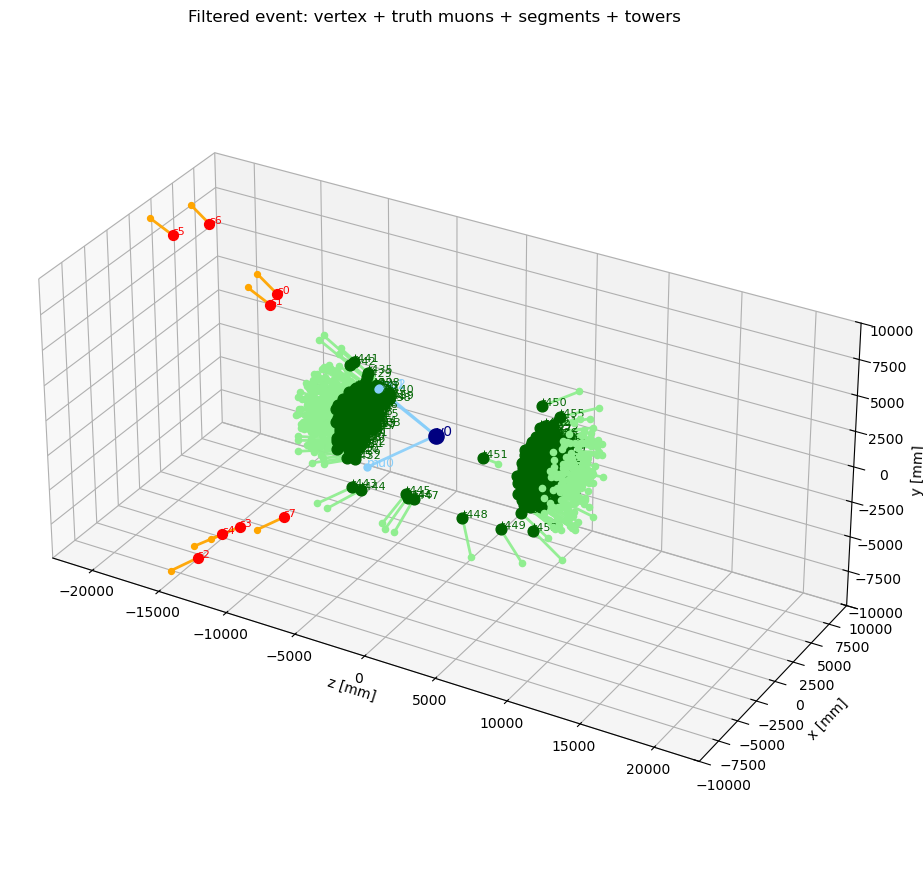

In [15]:
# ============================================================
# Plot one filtered event with:
#   - displaced vertex      : dark blue dot
#   - truth muon directions : light blue arrows
#   - segment positions     : red dots
#   - segment directions    : orange arrows
#   - calorimeter towers    : dark green dots + light green arrows
#
# Tower arrows:
#   built from tower_directionX/Y/Z
#
# Tower positions:
#   built from tower_eta, tower_phi assuming intersection with the
#   ATLAS calorimeter envelope:
#       barrel at r = R_MAX
#       endcap at z = +/- Z_MAX
#   and choosing the first surface hit along the ray from the origin.
#
# Same axis remapping as before:
#   plot X = physical z
#   plot Y = physical x
#   plot Z = physical y
# ============================================================

from operator import pos

import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX = 1                 # index in the FILTERED vertex tree
MUON_ARROW_LENGTH = 5000.0      # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH = 2500.0     # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

# Optional tower selection
MIN_TOWER_ENERGY_MEV = 1000.0      

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_calo(eta, phi, r_max=R_MAX, z_max=Z_MAX):
    """
    Build a 3D point from (eta, phi) by intersecting the ray from origin
    with the outer calorimeter envelope:
      - barrel cylinder: r = r_max
      - endcap planes  : z = +/- z_max

    Return (x, y, z) at the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Intersect barrel cylinder r = r_max
    u_r = np.hypot(ux, uy)
    if u_r > 0:
        t_barrel = r_max / u_r
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Intersect endcap z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the calorimeter envelope
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# Filter arrays
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find ALL MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Find ALL CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect tower positions and directions
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        pos = first_intersection_with_envelope(eta, phi, r_max=CALO_R_MAX, z_max=CALO_Z_MAX)
        
        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calo-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)

print("Total towers found after cuts:", len(tower_x_list))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # segment position remap
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction: (x, y, z) -> (z, x, y)
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # tower position remap
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(Xtow, Ytow, Ztow, f"t{itow}", fontsize=8, color=TOWER_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction: (x, y, z) -> (z, x, y)
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()


# dR filter

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 0
Event hash: (9009, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 2
Number of MuonBucketDump entries with same event hash: 3
Matching bucket indices: [8, 9, 10]
bucket entry 8: nSegments=0
bucket entry 9: nSegments=1
bucket entry 10: nSegments=0
Total segments found: 1
Total segment projections available for tower matching: 1
Number of CaloDump entries with same event hash: 1
Matching calo indices: [6]
calo entry 6: nTowers=3627
Total towers found after energy cut and ΔR matching: 6
Tower min ΔR stats: min=0.276, mean=0.326, max=0.351


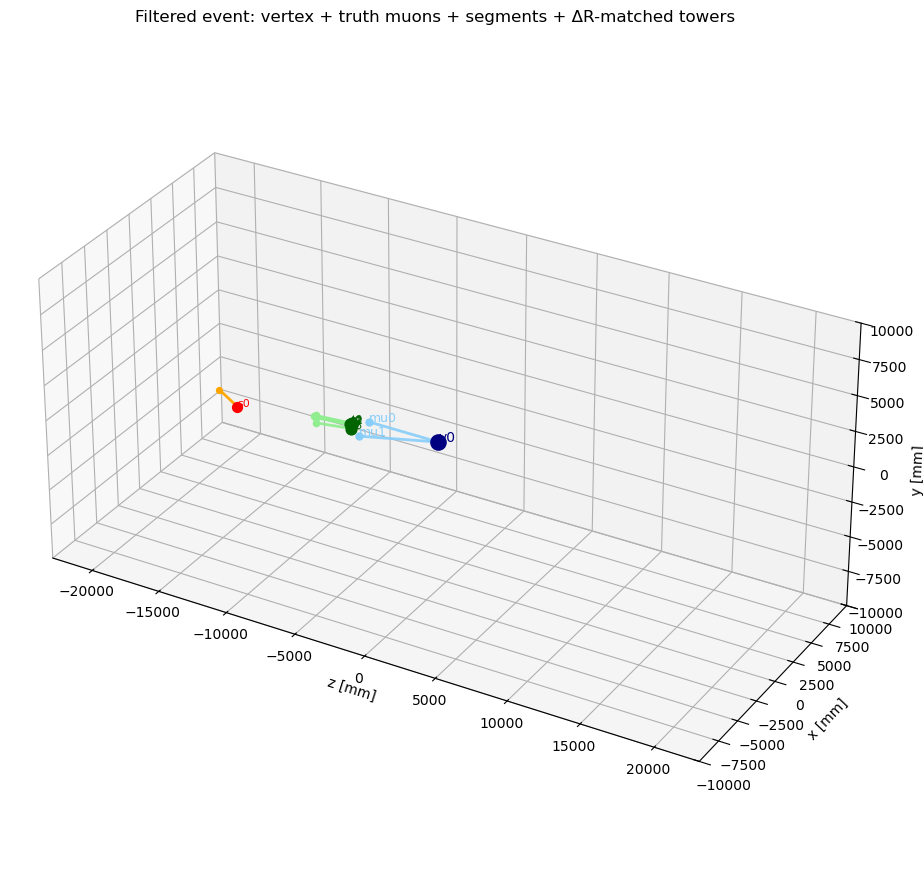

In [16]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX          = 0
MUON_ARROW_LENGTH    = 5000.0   # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH   = 2500.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4

# ------------------------------------------------------------
# Detector envelopes
# IMPORTANT:
#   - R_MAX, Z_MAX are your muon-system style limits already used
#   - CALO_R_MAX, CALO_Z_MAX are for placing tower points
# Replace these with your preferred calorimeter geometry if needed
# ------------------------------------------------------------
CALO_R_MAX = 4250.0   # mm
CALO_Z_MAX = 6500.0   # mm

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with:
      - barrel cylinder r = r_max
      - endcap planes  z = +/- z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcaps: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

def phi_from_xy(x, y):
    return np.arctan2(y, x)

def eta_from_xyz(x, y, z):
    """
    Pseudorapidity from a 3D position vector from the origin.
    """
    r = np.hypot(x, y)
    theta = np.arctan2(r, z)  # theta in [0, pi]
    # protect against theta -> 0 or pi
    eps = 1e-12
    theta = np.clip(theta, eps, np.pi - eps)
    return -np.log(np.tan(theta / 2.0))

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    dphi = delta_phi(phi1, phi2)
    deta = eta1 - eta2
    return np.hypot(deta, dphi)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the envelope used in your original selection
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Build segment projections in (eta, phi)
# using segment POSITION projected from origin
# ============================================================
seg_eta_list = []
seg_phi_list = []

for sx, sy, sz in zip(seg_x_list, seg_y_list, seg_z_list):
    seg_eta_list.append(float(eta_from_xyz(sx, sy, sz)))
    seg_phi_list.append(float(phi_from_xy(sx, sy)))

print("Total segment projections available for tower matching:", len(seg_eta_list))

# ============================================================
# Find all CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect and FILTER towers:
# keep only towers with min ΔR(tower, segment_position_projection) < 0.4
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []
tower_min_dr_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        # Require the tower to point to at least one segment in ΔR
        if len(seg_eta_list) == 0:
            continue

        dr_min = min(
            delta_r(eta, phi, seg_eta, seg_phi)
            for seg_eta, seg_phi in zip(seg_eta_list, seg_phi_list)
        )

        if dr_min >= MAX_TOWER_SEGMENT_DR:
            continue

        pos = first_intersection_with_envelope(
            eta, phi,
            r_max=CALO_R_MAX,
            z_max=CALO_Z_MAX
        )

        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calorimeter-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)
        tower_min_dr_list.append(dr_min)

print("Total towers found after energy cut and ΔR matching:", len(tower_x_list))
if len(tower_min_dr_list) > 0:
    print("Tower min ΔR stats: min={:.3f}, mean={:.3f}, max={:.3f}".format(
        np.min(tower_min_dr_list),
        np.mean(tower_min_dr_list),
        np.max(tower_min_dr_list)
    ))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot filtered tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(
        Xtow, Ytow, Ztow,
        f"t{itow}",
        fontsize=8,
        color=TOWER_POS_COLOR
    )

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + ΔR-matched towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 1
Event hash: (9014, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 10
Matching bucket indices: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
bucket entry 23: nSegments=1
bucket entry 24: nSegments=1
bucket entry 25: nSegments=1
bucket entry 26: nSegments=1
bucket entry 27: nSegments=1
bucket entry 28: nSegments=1
bucket entry 29: nSegments=1
bucket entry 30: nSegments=1
bucket entry 31: nSegments=0
bucket entry 32: nSegments=0
Total segments found: 8
Total segment projections available for tower matching: 8
Number of CaloDump entries with same event hash: 1
Matching calo indices: [11]
calo entry 11: nTowers=3743
Total towers found after energy cut and ΔR matching: 12
Tower min ΔR stats: min=0.017, mean=0.228, max=0.397


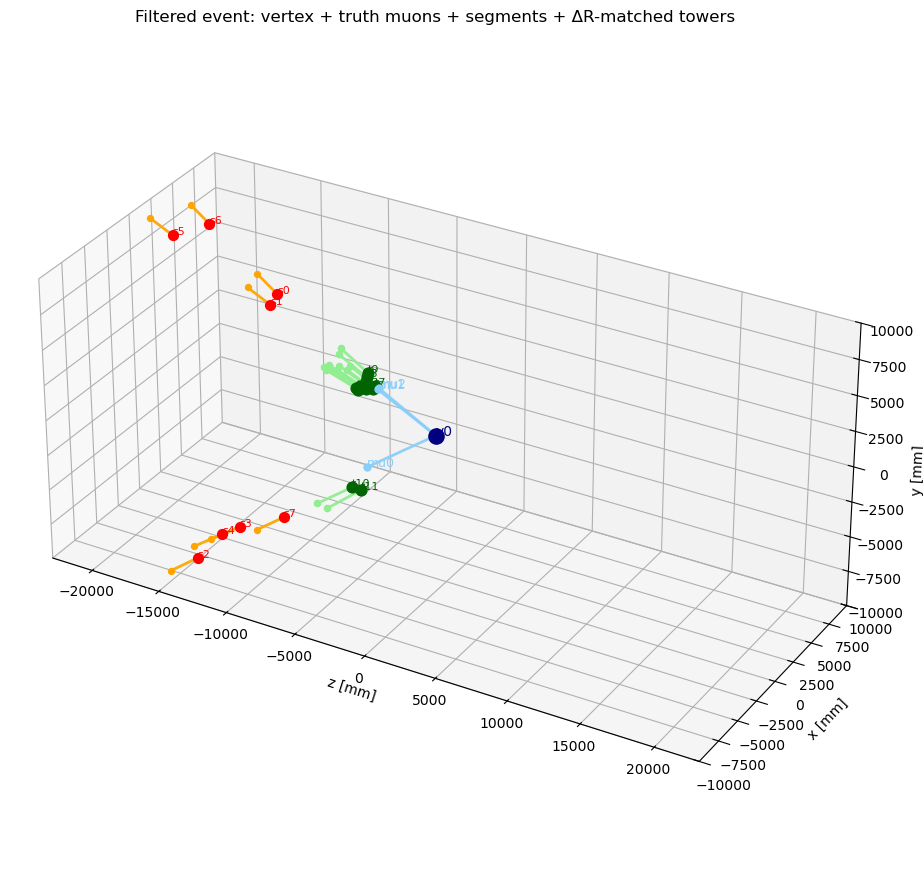

In [17]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX          = 1
MUON_ARROW_LENGTH    = 5000.0   # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH   = 2500.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4

# ------------------------------------------------------------
# Detector envelopes
# IMPORTANT:
#   - R_MAX, Z_MAX are your muon-system style limits already used
#   - CALO_R_MAX, CALO_Z_MAX are for placing tower points
# Replace these with your preferred calorimeter geometry if needed
# ------------------------------------------------------------
CALO_R_MAX = 4250.0   # mm
CALO_Z_MAX = 6500.0   # mm

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with:
      - barrel cylinder r = r_max
      - endcap planes  z = +/- z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcaps: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

def phi_from_xy(x, y):
    return np.arctan2(y, x)

def eta_from_xyz(x, y, z):
    """
    Pseudorapidity from a 3D position vector from the origin.
    """
    r = np.hypot(x, y)
    theta = np.arctan2(r, z)  # theta in [0, pi]
    # protect against theta -> 0 or pi
    eps = 1e-12
    theta = np.clip(theta, eps, np.pi - eps)
    return -np.log(np.tan(theta / 2.0))

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    dphi = delta_phi(phi1, phi2)
    deta = eta1 - eta2
    return np.hypot(deta, dphi)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the envelope used in your original selection
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Build segment projections in (eta, phi)
# using segment POSITION projected from origin
# ============================================================
seg_eta_list = []
seg_phi_list = []

for sx, sy, sz in zip(seg_x_list, seg_y_list, seg_z_list):
    seg_eta_list.append(float(eta_from_xyz(sx, sy, sz)))
    seg_phi_list.append(float(phi_from_xy(sx, sy)))

print("Total segment projections available for tower matching:", len(seg_eta_list))

# ============================================================
# Find all CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect and FILTER towers:
# keep only towers with min ΔR(tower, segment_position_projection) < 0.4
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []
tower_min_dr_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        # Require the tower to point to at least one segment in ΔR
        if len(seg_eta_list) == 0:
            continue

        dr_min = min(
            delta_r(eta, phi, seg_eta, seg_phi)
            for seg_eta, seg_phi in zip(seg_eta_list, seg_phi_list)
        )

        if dr_min >= MAX_TOWER_SEGMENT_DR:
            continue

        pos = first_intersection_with_envelope(
            eta, phi,
            r_max=CALO_R_MAX,
            z_max=CALO_Z_MAX
        )

        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calorimeter-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)
        tower_min_dr_list.append(dr_min)

print("Total towers found after energy cut and ΔR matching:", len(tower_x_list))
if len(tower_min_dr_list) > 0:
    print("Tower min ΔR stats: min={:.3f}, mean={:.3f}, max={:.3f}".format(
        np.min(tower_min_dr_list),
        np.mean(tower_min_dr_list),
        np.max(tower_min_dr_list)
    ))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot filtered tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(
        Xtow, Ytow, Ztow,
        f"t{itow}",
        fontsize=8,
        color=TOWER_POS_COLOR
    )

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + ΔR-matched towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 2
Event hash: (9016, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 8
Matching bucket indices: [33, 34, 35, 36, 37, 38, 39, 40]
bucket entry 33: nSegments=1
bucket entry 34: nSegments=2
bucket entry 35: nSegments=1
bucket entry 36: nSegments=1
bucket entry 37: nSegments=2
bucket entry 38: nSegments=2
bucket entry 39: nSegments=0
bucket entry 40: nSegments=0
Total segments found: 9
Total segment projections available for tower matching: 9
Number of CaloDump entries with same event hash: 1
Matching calo indices: [12]
calo entry 12: nTowers=3565
Total towers found after energy cut and ΔR matching: 16
Tower min ΔR stats: min=0.042, mean=0.210, max=0.395


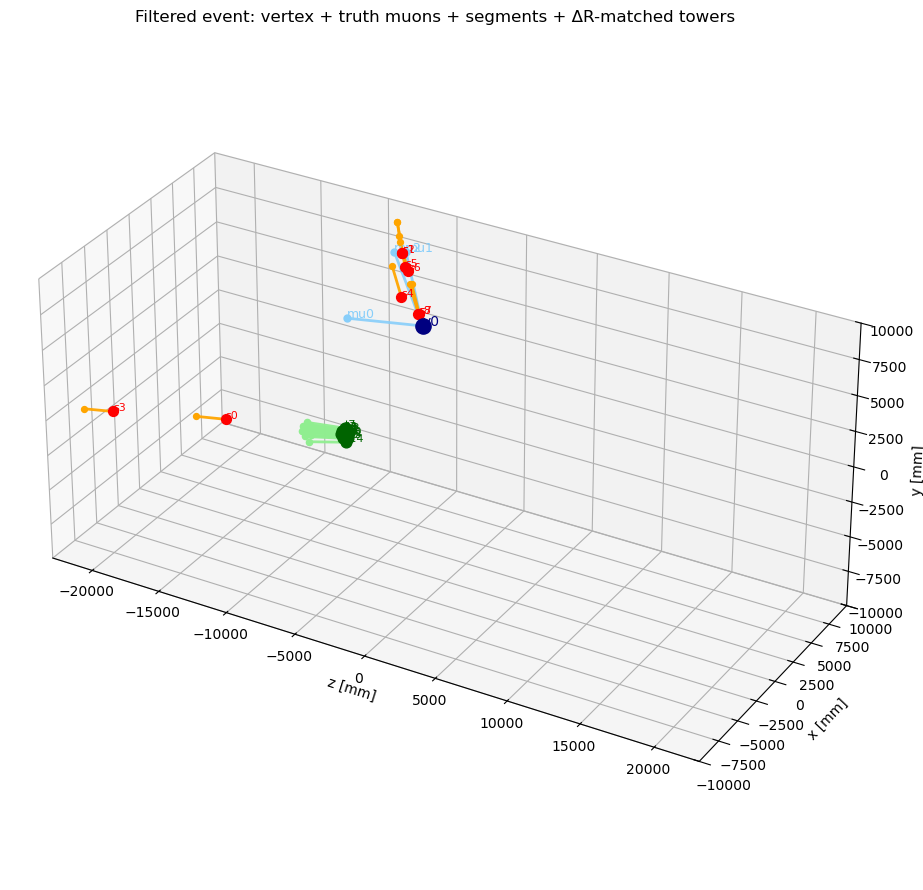

In [18]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX          = 2
MUON_ARROW_LENGTH    = 5000.0   # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH   = 2500.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4

# ------------------------------------------------------------
# Detector envelopes
# IMPORTANT:
#   - R_MAX, Z_MAX are your muon-system style limits already used
#   - CALO_R_MAX, CALO_Z_MAX are for placing tower points
# Replace these with your preferred calorimeter geometry if needed
# ------------------------------------------------------------
CALO_R_MAX = 4250.0   # mm
CALO_Z_MAX = 6500.0   # mm

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with:
      - barrel cylinder r = r_max
      - endcap planes  z = +/- z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcaps: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

def phi_from_xy(x, y):
    return np.arctan2(y, x)

def eta_from_xyz(x, y, z):
    """
    Pseudorapidity from a 3D position vector from the origin.
    """
    r = np.hypot(x, y)
    theta = np.arctan2(r, z)  # theta in [0, pi]
    # protect against theta -> 0 or pi
    eps = 1e-12
    theta = np.clip(theta, eps, np.pi - eps)
    return -np.log(np.tan(theta / 2.0))

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    dphi = delta_phi(phi1, phi2)
    deta = eta1 - eta2
    return np.hypot(deta, dphi)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the envelope used in your original selection
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Build segment projections in (eta, phi)
# using segment POSITION projected from origin
# ============================================================
seg_eta_list = []
seg_phi_list = []

for sx, sy, sz in zip(seg_x_list, seg_y_list, seg_z_list):
    seg_eta_list.append(float(eta_from_xyz(sx, sy, sz)))
    seg_phi_list.append(float(phi_from_xy(sx, sy)))

print("Total segment projections available for tower matching:", len(seg_eta_list))

# ============================================================
# Find all CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect and FILTER towers:
# keep only towers with min ΔR(tower, segment_position_projection) < 0.4
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []
tower_min_dr_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        # Require the tower to point to at least one segment in ΔR
        if len(seg_eta_list) == 0:
            continue

        dr_min = min(
            delta_r(eta, phi, seg_eta, seg_phi)
            for seg_eta, seg_phi in zip(seg_eta_list, seg_phi_list)
        )

        if dr_min >= MAX_TOWER_SEGMENT_DR:
            continue

        pos = first_intersection_with_envelope(
            eta, phi,
            r_max=CALO_R_MAX,
            z_max=CALO_Z_MAX
        )

        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calorimeter-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)
        tower_min_dr_list.append(dr_min)

print("Total towers found after energy cut and ΔR matching:", len(tower_x_list))
if len(tower_min_dr_list) > 0:
    print("Tower min ΔR stats: min={:.3f}, mean={:.3f}, max={:.3f}".format(
        np.min(tower_min_dr_list),
        np.mean(tower_min_dr_list),
        np.max(tower_min_dr_list)
    ))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot filtered tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(
        Xtow, Ytow, Ztow,
        f"t{itow}",
        fontsize=8,
        color=TOWER_POS_COLOR
    )

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + ΔR-matched towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 3
Event hash: (9008, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 6
Matching bucket indices: [41, 42, 43, 44, 45, 46]
bucket entry 41: nSegments=0
bucket entry 42: nSegments=2
bucket entry 43: nSegments=2
bucket entry 44: nSegments=1
bucket entry 45: nSegments=2
bucket entry 46: nSegments=1
Total segments found: 8
Total segment projections available for tower matching: 8
Number of CaloDump entries with same event hash: 1
Matching calo indices: [10]
calo entry 10: nTowers=3903
Total towers found after energy cut and ΔR matching: 3
Tower min ΔR stats: min=0.020, mean=0.048, max=0.098


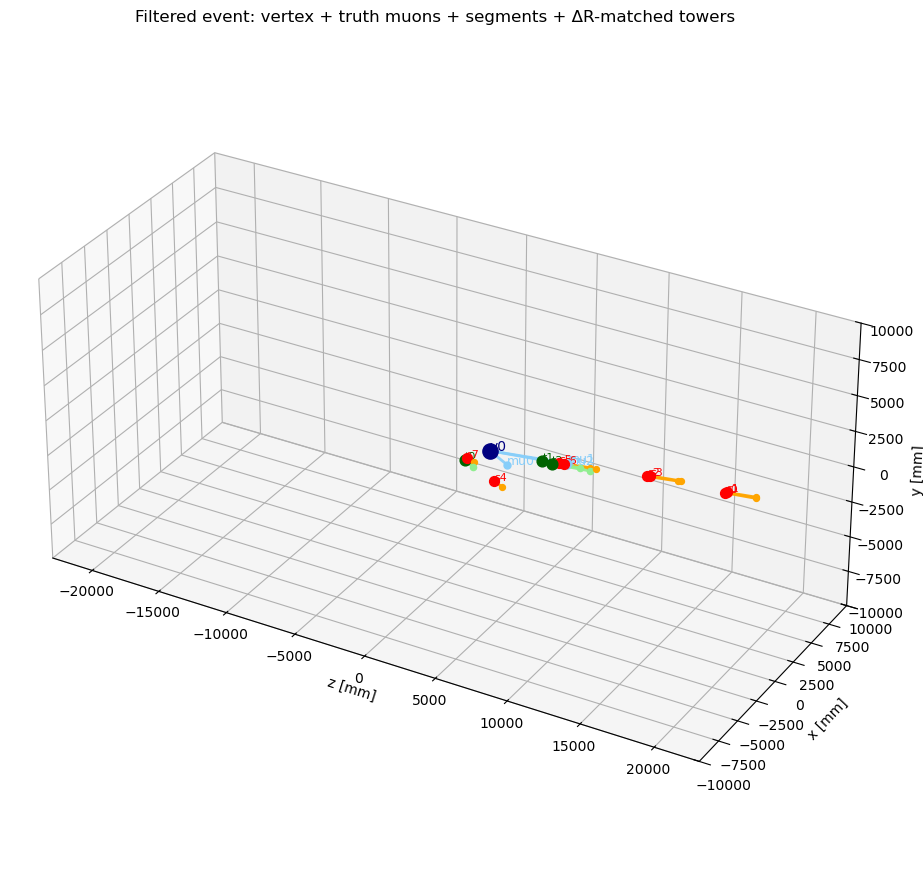

In [19]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX          = 3
MUON_ARROW_LENGTH    = 5000.0   # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH   = 2500.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4

# ------------------------------------------------------------
# Detector envelopes
# IMPORTANT:
#   - R_MAX, Z_MAX are your muon-system style limits already used
#   - CALO_R_MAX, CALO_Z_MAX are for placing tower points
# Replace these with your preferred calorimeter geometry if needed
# ------------------------------------------------------------
CALO_R_MAX = 4250.0   # mm
CALO_Z_MAX = 6500.0   # mm

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with:
      - barrel cylinder r = r_max
      - endcap planes  z = +/- z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcaps: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

def phi_from_xy(x, y):
    return np.arctan2(y, x)

def eta_from_xyz(x, y, z):
    """
    Pseudorapidity from a 3D position vector from the origin.
    """
    r = np.hypot(x, y)
    theta = np.arctan2(r, z)  # theta in [0, pi]
    # protect against theta -> 0 or pi
    eps = 1e-12
    theta = np.clip(theta, eps, np.pi - eps)
    return -np.log(np.tan(theta / 2.0))

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    dphi = delta_phi(phi1, phi2)
    deta = eta1 - eta2
    return np.hypot(deta, dphi)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the envelope used in your original selection
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Build segment projections in (eta, phi)
# using segment POSITION projected from origin
# ============================================================
seg_eta_list = []
seg_phi_list = []

for sx, sy, sz in zip(seg_x_list, seg_y_list, seg_z_list):
    seg_eta_list.append(float(eta_from_xyz(sx, sy, sz)))
    seg_phi_list.append(float(phi_from_xy(sx, sy)))

print("Total segment projections available for tower matching:", len(seg_eta_list))

# ============================================================
# Find all CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect and FILTER towers:
# keep only towers with min ΔR(tower, segment_position_projection) < 0.4
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []
tower_min_dr_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        # Require the tower to point to at least one segment in ΔR
        if len(seg_eta_list) == 0:
            continue

        dr_min = min(
            delta_r(eta, phi, seg_eta, seg_phi)
            for seg_eta, seg_phi in zip(seg_eta_list, seg_phi_list)
        )

        if dr_min >= MAX_TOWER_SEGMENT_DR:
            continue

        pos = first_intersection_with_envelope(
            eta, phi,
            r_max=CALO_R_MAX,
            z_max=CALO_Z_MAX
        )

        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calorimeter-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)
        tower_min_dr_list.append(dr_min)

print("Total towers found after energy cut and ΔR matching:", len(tower_x_list))
if len(tower_min_dr_list) > 0:
    print("Tower min ΔR stats: min={:.3f}, mean={:.3f}, max={:.3f}".format(
        np.min(tower_min_dr_list),
        np.mean(tower_min_dr_list),
        np.max(tower_min_dr_list)
    ))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot filtered tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(
        Xtow, Ytow, Ztow,
        f"t{itow}",
        fontsize=8,
        color=TOWER_POS_COLOR
    )

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + ΔR-matched towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 4
Event hash: (9012, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 8
Matching bucket indices: [61, 62, 63, 64, 65, 66, 67, 68]
bucket entry 61: nSegments=0
bucket entry 62: nSegments=1
bucket entry 63: nSegments=2
bucket entry 64: nSegments=1
bucket entry 65: nSegments=2
bucket entry 66: nSegments=1
bucket entry 67: nSegments=0
bucket entry 68: nSegments=0
Total segments found: 7
Total segment projections available for tower matching: 7
Number of CaloDump entries with same event hash: 1
Matching calo indices: [14]
calo entry 14: nTowers=4017
Total towers found after energy cut and ΔR matching: 39
Tower min ΔR stats: min=0.033, mean=0.235, max=0.393


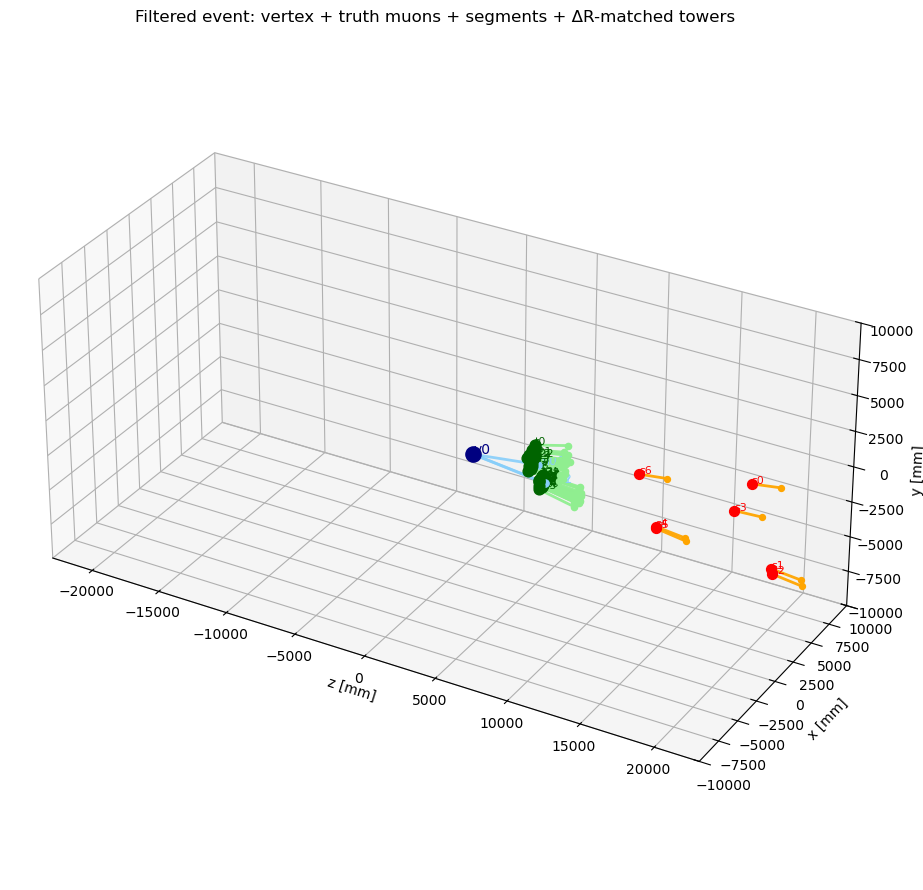

In [20]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX          = 4
MUON_ARROW_LENGTH    = 5000.0   # mm
SEGMENT_ARROW_LENGTH = 2000.0   # mm
TOWER_ARROW_LENGTH   = 2500.0   # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SEGMENT_POS_COLOR = "red"
SEGMENT_DIR_COLOR = "orange"
TOWER_POS_COLOR = "darkgreen"
TOWER_DIR_COLOR = "lightgreen"

MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4

# ------------------------------------------------------------
# Detector envelopes
# IMPORTANT:
#   - R_MAX, Z_MAX are your muon-system style limits already used
#   - CALO_R_MAX, CALO_Z_MAX are for placing tower points
# Replace these with your preferred calorimeter geometry if needed
# ------------------------------------------------------------
CALO_R_MAX = 4250.0   # mm
CALO_Z_MAX = 6500.0   # mm

# ============================================================
# Helpers
# ============================================================
def eta_to_theta(eta):
    return 2.0 * np.arctan(np.exp(-eta))

def direction_from_eta_phi(eta, phi):
    theta = eta_to_theta(eta)
    st = np.sin(theta)
    return np.array([
        st * np.cos(phi),
        st * np.sin(phi),
        np.cos(theta)
    ], dtype=float)

def first_intersection_with_envelope(eta, phi, r_max, z_max):
    """
    Ray from origin in direction (eta, phi), intersected with:
      - barrel cylinder r = r_max
      - endcap planes  z = +/- z_max

    Returns (x, y, z) for the first positive intersection.
    """
    u = direction_from_eta_phi(eta, phi)
    ux, uy, uz = u

    candidates = []

    # Barrel: r = r_max
    ur = np.hypot(ux, uy)
    if ur > 0:
        t_barrel = r_max / ur
        z_barrel = t_barrel * uz
        if np.abs(z_barrel) <= z_max:
            candidates.append(t_barrel)

    # Endcaps: z = +/- z_max
    if np.abs(uz) > 0:
        t_endcap = z_max / np.abs(uz)
        x_end = t_endcap * ux
        y_end = t_endcap * uy
        r_end = np.hypot(x_end, y_end)
        if r_end <= r_max:
            candidates.append(t_endcap)

    if not candidates:
        return None

    t = min(tc for tc in candidates if tc > 0)
    x, y, z = t * u
    return float(x), float(y), float(z)

def phi_from_xy(x, y):
    return np.arctan2(y, x)

def eta_from_xyz(x, y, z):
    """
    Pseudorapidity from a 3D position vector from the origin.
    """
    r = np.hypot(x, y)
    theta = np.arctan2(r, z)  # theta in [0, pi]
    # protect against theta -> 0 or pi
    eps = 1e-12
    theta = np.clip(theta, eps, np.pi - eps)
    return -np.log(np.tan(theta / 2.0))

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    dphi = delta_phi(phi1, phi2)
    deta = eta1 - eta2
    return np.hypot(deta, dphi)

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")
calo_tree   = _open_tree_by_name(ROOT_FILE, "CaloDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the envelope used in your original selection
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))
calo_keys   = _normalize_keys(list(calo_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]
calo_hash_branch   = calo_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()
calo_hashes_all   = calo_tree[calo_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect segment positions and directions
# ============================================================
seg_x_list = []
seg_y_list = []
seg_z_list = []

seg_dx_list = []
seg_dy_list = []
seg_dz_list = []

for i in matching_bucket_indices:
    segx = bucket_tree["segmentPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    segy = bucket_tree["segmentPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    segz = bucket_tree["segmentPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    dirx = bucket_tree["segmentDirectionX"].array(entry_start=i, entry_stop=i+1)[0]
    diry = bucket_tree["segmentDirectionY"].array(entry_start=i, entry_stop=i+1)[0]
    dirz = bucket_tree["segmentDirectionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nseg = len(segx)
    print(f"bucket entry {i}: nSegments={nseg}")

    for j in range(nseg):
        seg_x_list.append(float(segx[j]))
        seg_y_list.append(float(segy[j]))
        seg_z_list.append(float(segz[j]))

        seg_dx_list.append(float(dirx[j]))
        seg_dy_list.append(float(diry[j]))
        seg_dz_list.append(float(dirz[j]))

print("Total segments found:", len(seg_x_list))

# ============================================================
# Build segment projections in (eta, phi)
# using segment POSITION projected from origin
# ============================================================
seg_eta_list = []
seg_phi_list = []

for sx, sy, sz in zip(seg_x_list, seg_y_list, seg_z_list):
    seg_eta_list.append(float(eta_from_xyz(sx, sy, sz)))
    seg_phi_list.append(float(phi_from_xy(sx, sy)))

print("Total segment projections available for tower matching:", len(seg_eta_list))

# ============================================================
# Find all CaloDump entries with same event hash
# ============================================================
matching_calo_indices = [
    i for i, h in enumerate(calo_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of CaloDump entries with same event hash:",
      len(matching_calo_indices))
print("Matching calo indices:", matching_calo_indices)

# ============================================================
# Collect and FILTER towers:
# keep only towers with min ΔR(tower, segment_position_projection) < 0.4
# ============================================================
tower_x_list = []
tower_y_list = []
tower_z_list = []

tower_dx_list = []
tower_dy_list = []
tower_dz_list = []

tower_e_list = []
tower_eta_list = []
tower_phi_list = []
tower_min_dr_list = []

for i in matching_calo_indices:
    tdx = calo_tree["tower_directionX"].array(entry_start=i, entry_stop=i+1)[0]
    tdy = calo_tree["tower_directionY"].array(entry_start=i, entry_stop=i+1)[0]
    tdz = calo_tree["tower_directionZ"].array(entry_start=i, entry_stop=i+1)[0]

    teta = calo_tree["tower_eta"].array(entry_start=i, entry_stop=i+1)[0]
    tphi = calo_tree["tower_phi"].array(entry_start=i, entry_stop=i+1)[0]
    tene = calo_tree["tower_energy_mev"].array(entry_start=i, entry_stop=i+1)[0]

    ntow = len(teta)
    print(f"calo entry {i}: nTowers={ntow}")

    for j in range(ntow):
        e = float(tene[j])
        if e < MIN_TOWER_ENERGY_MEV:
            continue

        eta = float(teta[j])
        phi = float(tphi[j])

        # Require the tower to point to at least one segment in ΔR
        if len(seg_eta_list) == 0:
            continue

        dr_min = min(
            delta_r(eta, phi, seg_eta, seg_phi)
            for seg_eta, seg_phi in zip(seg_eta_list, seg_phi_list)
        )

        if dr_min >= MAX_TOWER_SEGMENT_DR:
            continue

        pos = first_intersection_with_envelope(
            eta, phi,
            r_max=CALO_R_MAX,
            z_max=CALO_Z_MAX
        )

        if pos is None:
            print(f"Skipping tower {j} in calo entry {i}: no calorimeter-envelope intersection")
            continue

        x, y, z = pos

        tower_x_list.append(x)
        tower_y_list.append(y)
        tower_z_list.append(z)

        tower_dx_list.append(float(tdx[j]))
        tower_dy_list.append(float(tdy[j]))
        tower_dz_list.append(float(tdz[j]))

        tower_e_list.append(e)
        tower_eta_list.append(eta)
        tower_phi_list.append(phi)
        tower_min_dr_list.append(dr_min)

print("Total towers found after energy cut and ΔR matching:", len(tower_x_list))
if len(tower_min_dr_list) > 0:
    print("Tower min ΔR stats: min={:.3f}, mean={:.3f}, max={:.3f}".format(
        np.min(tower_min_dr_list),
        np.mean(tower_min_dr_list),
        np.max(tower_min_dr_list)
    ))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot segment positions (red) and directions (orange)
# ------------------------------------------------------------
for iseg in range(len(seg_x_list)):
    sx = seg_x_list[iseg]
    sy = seg_y_list[iseg]
    sz = seg_z_list[iseg]

    dx = seg_dx_list[iseg]
    dy = seg_dy_list[iseg]
    dz = seg_dz_list[iseg]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=50, color=SEGMENT_POS_COLOR)
    ax.text(Xs, Ys, Zs, f"s{iseg}", fontsize=8, color=SEGMENT_POS_COLOR)

    if dnorm == 0:
        print(f"Skipping segment {iseg}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = SEGMENT_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xt = Xs + dX
    Yt = Ys + dY
    Zt = Zs + dZ

    ax.plot(
        [Xs, Xt],
        [Ys, Yt],
        [Zs, Zt],
        color=SEGMENT_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xt, Yt, Zt, color=SEGMENT_DIR_COLOR, s=18)

# ------------------------------------------------------------
# 4) Plot filtered tower positions (dark green) and directions (light green)
# ------------------------------------------------------------
for itow in range(len(tower_x_list)):
    tx = tower_x_list[itow]
    ty = tower_y_list[itow]
    tz = tower_z_list[itow]

    dx = tower_dx_list[itow]
    dy = tower_dy_list[itow]
    dz = tower_dz_list[itow]

    dvec = np.array([dx, dy, dz], dtype=float)
    dnorm = np.linalg.norm(dvec)

    # remap position
    Xtow = tz
    Ytow = tx
    Ztow = ty

    ax.scatter(Xtow, Ytow, Ztow, s=60, color=TOWER_POS_COLOR)
    ax.text(
        Xtow, Ytow, Ztow,
        f"t{itow}",
        fontsize=8,
        color=TOWER_POS_COLOR
    )

    if dnorm == 0:
        print(f"Skipping tower {itow}: zero direction vector")
        continue

    dunit = dvec / dnorm
    ddx_phys, ddy_phys, ddz_phys = TOWER_ARROW_LENGTH * dunit

    # remap direction
    dX = ddz_phys
    dY = ddx_phys
    dZ = ddy_phys

    Xtip = Xtow + dX
    Ytip = Ytow + dY
    Ztip = Ztow + dZ

    ax.plot(
        [Xtow, Xtip],
        [Ytow, Ytip],
        [Ztow, Ztip],
        color=TOWER_DIR_COLOR,
        linewidth=2.0,
        alpha=0.95
    )
    ax.scatter(Xtip, Ytip, Ztip, color=TOWER_DIR_COLOR, s=20)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + segments + ΔR-matched towers")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

# Muon buckets!

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 0
Event hash: (9009, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 2
Number of MuonBucketDump entries with same event hash: 3
Matching bucket indices: [8, 9, 10]
bucket entry 8: nSpacePoints=3
bucket entry 9: nSpacePoints=6
bucket entry 10: nSpacePoints=28
Total space points found: 37


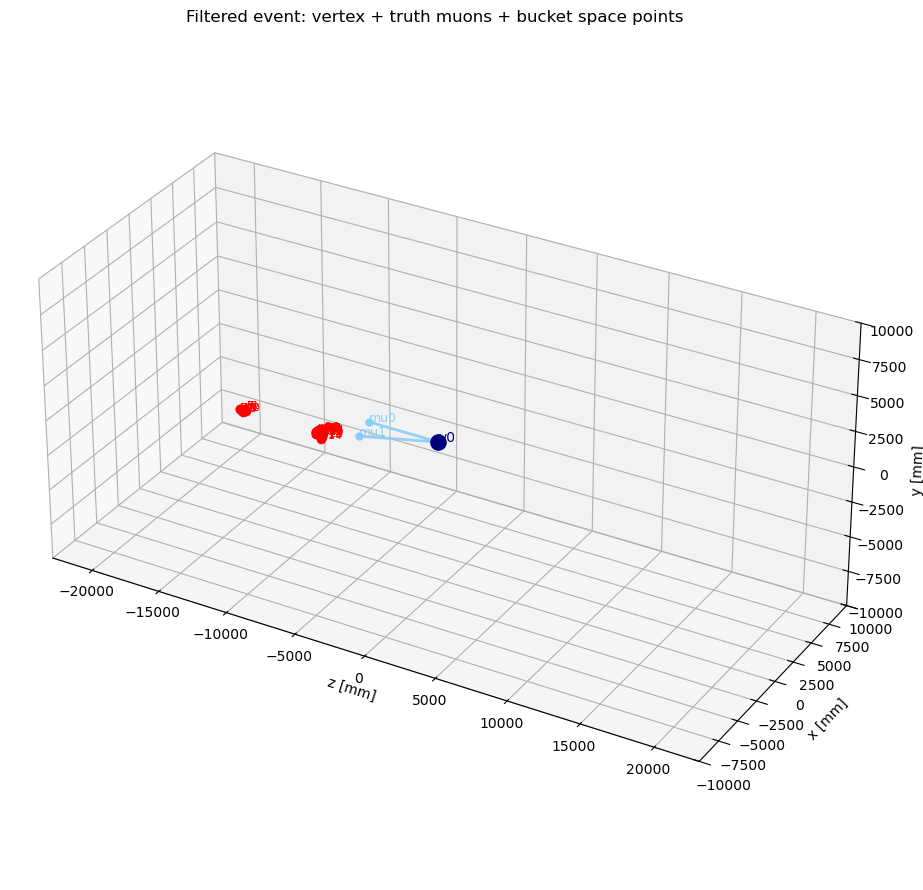

In [21]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX = 0            # index in the FILTERED vertex tree
MUON_ARROW_LENGTH = 5000.0 # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SPACEPOINT_COLOR = "red"

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the calorimeter envelope
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect bucket space points
# ============================================================
sp_x_list = []
sp_y_list = []
sp_z_list = []

for i in matching_bucket_indices:
    gx = bucket_tree["globalPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    gy = bucket_tree["globalPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    gz = bucket_tree["globalPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nsp = len(gx)
    print(f"bucket entry {i}: nSpacePoints={nsp}")

    for j in range(nsp):
        sp_x_list.append(float(gx[j]))
        sp_y_list.append(float(gy[j]))
        sp_z_list.append(float(gz[j]))

print("Total space points found:", len(sp_x_list))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot bucket space points (red)
# ------------------------------------------------------------
for isp in range(len(sp_x_list)):
    sx = sp_x_list[isp]
    sy = sp_y_list[isp]
    sz = sp_z_list[isp]

    # remap: (x, y, z) -> (z, x, y)
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=35, color=SPACEPOINT_COLOR)
    ax.text(Xs, Ys, Zs, f"p{isp}", fontsize=8, color=SPACEPOINT_COLOR)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + bucket space points")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()

Total events before filtering : 3000
Events kept inside calo       : 675
Events removed outside calo   : 2325

Using filtered event index 1
Event hash: (9014, 2211873798111632)
Number of vertices in event: 1
Number of muons in event   : 3
Number of MuonBucketDump entries with same event hash: 10
Matching bucket indices: [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
bucket entry 23: nSpacePoints=15
bucket entry 24: nSpacePoints=13
bucket entry 25: nSpacePoints=15
bucket entry 26: nSpacePoints=9
bucket entry 27: nSpacePoints=5
bucket entry 28: nSpacePoints=6
bucket entry 29: nSpacePoints=6
bucket entry 30: nSpacePoints=7
bucket entry 31: nSpacePoints=14
bucket entry 32: nSpacePoints=49
Total space points found: 139


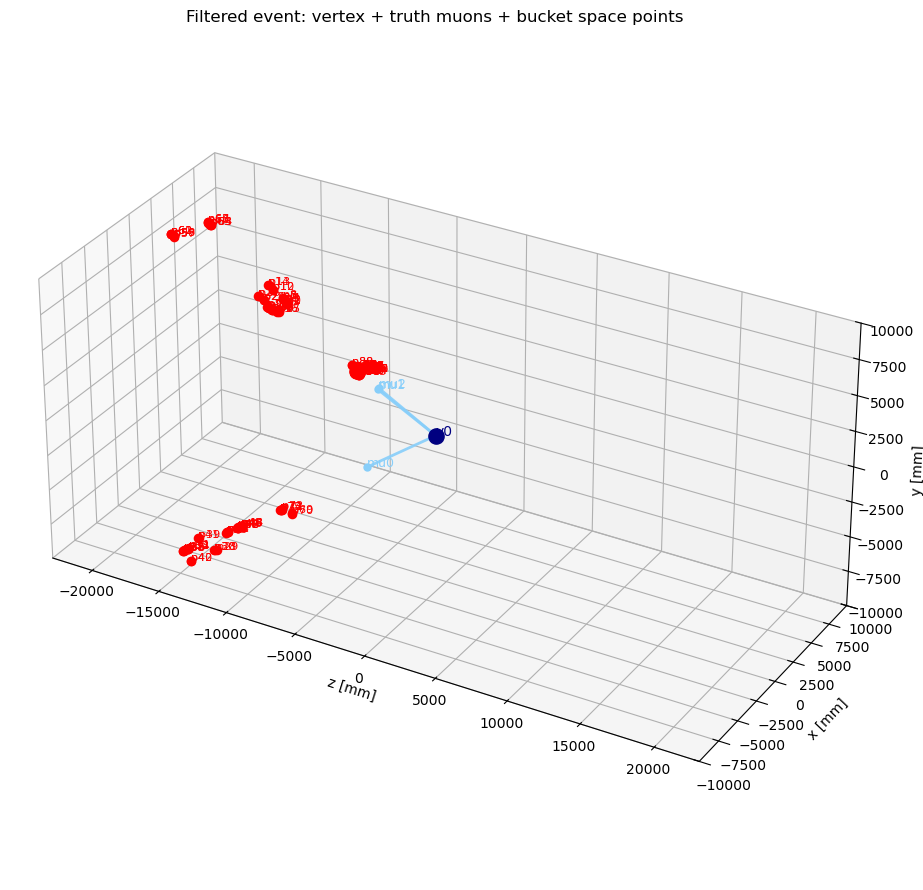

In [22]:
# ------------------------------------------------------------
# Tunable plotting parameters
# ------------------------------------------------------------
EVENT_INDEX = 1            # index in the FILTERED vertex tree
MUON_ARROW_LENGTH = 5000.0 # mm

VERTEX_COLOR = "navy"
MUON_COLOR = "lightskyblue"
SPACEPOINT_COLOR = "red"

# ============================================================
# Read trees
# ============================================================
vertex_tree = _open_tree_by_name(ROOT_FILE, "MuonVertexDump")
bucket_tree = _open_tree_by_name(ROOT_FILE, "MuonBucketDump")

# ============================================================
# Read vertex and truth-muon branches
# ============================================================
vertex_x_all = vertex_tree["truthMuonVertexPositionX"].array()
vertex_y_all = vertex_tree["truthMuonVertexPositionY"].array()
vertex_z_all = vertex_tree["truthMuonVertexPositionZ"].array()

muon_pt_all  = vertex_tree["truthMuon_pt"].array()
muon_eta_all = vertex_tree["truthMuon_eta"].array()
muon_phi_all = vertex_tree["truthMuon_phi"].array()

# ============================================================
# Filter events: keep only events where ALL vertices are inside
# the calorimeter envelope
# ============================================================
vertex_r = np.sqrt(vertex_x_all**2 + vertex_y_all**2)
vertex_inside = (vertex_r <= R_MAX) & (np.abs(vertex_z_all) <= Z_MAX)
event_mask = ak.all(vertex_inside, axis=1)

print(f"Total events before filtering : {len(event_mask)}")
print(f"Events kept inside calo       : {ak.sum(event_mask)}")
print(f"Events removed outside calo   : {len(event_mask) - ak.sum(event_mask)}")

if ak.sum(event_mask) == 0:
    raise RuntimeError("No events passed the calorimeter-envelope filter.")

# ============================================================
# Filter arrays
# ============================================================
vertex_x_filt = vertex_x_all[event_mask]
vertex_y_filt = vertex_y_all[event_mask]
vertex_z_filt = vertex_z_all[event_mask]

muon_pt_filt  = muon_pt_all[event_mask]
muon_eta_filt = muon_eta_all[event_mask]
muon_phi_filt = muon_phi_all[event_mask]

# ============================================================
# Get event hash for the chosen FILTERED event
# ============================================================
vertex_keys = _normalize_keys(list(vertex_tree.keys()))
bucket_keys = _normalize_keys(list(bucket_tree.keys()))

vertex_hash_branch = vertex_keys["CommonEventHash"]
bucket_hash_branch = bucket_keys["CommonEventHash"]

vertex_hashes_all = vertex_tree[vertex_hash_branch].array()
bucket_hashes_all = bucket_tree[bucket_hash_branch].array()

vertex_hashes_filt = vertex_hashes_all[event_mask]
event_hash = _flatten_event_hash(vertex_hashes_filt[EVENT_INDEX])

print(f"\nUsing filtered event index {EVENT_INDEX}")
print("Event hash:", event_hash)

# ============================================================
# Get vertices and muons for this filtered event
# ============================================================
vx_evt = vertex_x_filt[EVENT_INDEX]
vy_evt = vertex_y_filt[EVENT_INDEX]
vz_evt = vertex_z_filt[EVENT_INDEX]

mu_pt  = muon_pt_filt[EVENT_INDEX]
mu_eta = muon_eta_filt[EVENT_INDEX]
mu_phi = muon_phi_filt[EVENT_INDEX]

print("Number of vertices in event:", len(vx_evt))
print("Number of muons in event   :", len(mu_pt))

# Simple visualization choice:
# connect every vertex to every muon
n_vertices = len(vx_evt)
n_muons = len(mu_pt)
mu_links = [list(range(n_muons)) for _ in range(n_vertices)]

# ============================================================
# Find all MuonBucketDump entries with same event hash
# ============================================================
matching_bucket_indices = [
    i for i, h in enumerate(bucket_hashes_all)
    if _flatten_event_hash(h) == event_hash
]

print("Number of MuonBucketDump entries with same event hash:",
      len(matching_bucket_indices))
print("Matching bucket indices:", matching_bucket_indices)

# ============================================================
# Collect bucket space points
# ============================================================
sp_x_list = []
sp_y_list = []
sp_z_list = []

for i in matching_bucket_indices:
    gx = bucket_tree["globalPositionX"].array(entry_start=i, entry_stop=i+1)[0]
    gy = bucket_tree["globalPositionY"].array(entry_start=i, entry_stop=i+1)[0]
    gz = bucket_tree["globalPositionZ"].array(entry_start=i, entry_stop=i+1)[0]

    nsp = len(gx)
    print(f"bucket entry {i}: nSpacePoints={nsp}")

    for j in range(nsp):
        sp_x_list.append(float(gx[j]))
        sp_y_list.append(float(gy[j]))
        sp_z_list.append(float(gz[j]))

print("Total space points found:", len(sp_x_list))

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 1) Plot vertices (dark blue)
# ------------------------------------------------------------
for ivtx in range(len(vx_evt)):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    # remap: (x, y, z) -> (z, x, y)
    Xv = zv
    Yv = xv
    Zv = yv

    ax.scatter(Xv, Yv, Zv, s=120, color=VERTEX_COLOR)
    ax.text(Xv, Yv, Zv, f"v{ivtx}", fontsize=10, color=VERTEX_COLOR)

# ------------------------------------------------------------
# 2) Plot truth muons (light blue arrows)
# ------------------------------------------------------------
for ivtx, links in enumerate(mu_links):
    xv = float(vx_evt[ivtx])
    yv = float(vy_evt[ivtx])
    zv = float(vz_evt[ivtx])

    Xv = zv
    Yv = xv
    Zv = yv

    for imu in links:
        imu = int(imu)

        pt  = float(mu_pt[imu])
        eta = float(mu_eta[imu])
        phi = float(mu_phi[imu])

        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)

        pvec = np.array([px, py, pz], dtype=float)
        pnorm = np.linalg.norm(pvec)

        if pnorm == 0:
            print(f"Skipping muon {imu}: zero momentum")
            continue

        direction = pvec / pnorm
        dx_phys, dy_phys, dz_phys = MUON_ARROW_LENGTH * direction

        # remap direction: (x, y, z) -> (z, x, y)
        dX = dz_phys
        dY = dx_phys
        dZ = dy_phys

        Xt = Xv + dX
        Yt = Yv + dY
        Zt = Zv + dZ

        ax.plot(
            [Xv, Xt],
            [Yv, Yt],
            [Zv, Zt],
            color=MUON_COLOR,
            linewidth=2.0,
            alpha=0.9
        )
        ax.scatter(Xt, Yt, Zt, color=MUON_COLOR, s=25)
        ax.text(Xt, Yt, Zt, f"mu{imu}", fontsize=9, color=MUON_COLOR)

# ------------------------------------------------------------
# 3) Plot bucket space points (red)
# ------------------------------------------------------------
for isp in range(len(sp_x_list)):
    sx = sp_x_list[isp]
    sy = sp_y_list[isp]
    sz = sp_z_list[isp]

    # remap: (x, y, z) -> (z, x, y)
    Xs = sz
    Ys = sx
    Zs = sy

    ax.scatter(Xs, Ys, Zs, s=35, color=SPACEPOINT_COLOR)
    ax.text(Xs, Ys, Zs, f"p{isp}", fontsize=8, color=SPACEPOINT_COLOR)

# ============================================================
# Axes / view
# ============================================================
ax.set_xlabel("z [mm]")
ax.set_ylabel("x [mm]")
ax.set_zlabel("y [mm]")

ax.set_xlim(-23000, 23000)
ax.set_ylim(-10000, 10000)
ax.set_zlim(-10000, 10000)

ax.set_title("Filtered event: vertex + truth muons + bucket space points")
ax.set_box_aspect([46000, 20000, 20000])

plt.tight_layout()
plt.show()